# 05 — Index C (Energy-Pulse)

**Objetivo.** Resolver Index_C con el menor RMSE de backtest 252d, decidido por backtest.

**Pistas del enunciado.** Energy-Pulse — el enunciado sugiere features macro (crudo, oro, tipos).
**El análisis de datos lo desmiente como vía principal** (ver abajo).

**Hallazgos del análisis previo (importante).**
- `corr(ret_C, Δmacro)` es **solo contemporánea** (~+0.20 a lag 0) y **cae a cero a lag≥1**:
  el macro de hoy acompaña a C hoy, pero el de ayer NO predice C hoy → poco útil para forecasting.
- `test_macro` cubre **solo 173 de los 252 días** a predecir. El rollout necesita aux para los 252;
  rellenar 79 días mete ruido justo al final, donde el error ya se ha acumulado.
- Las correlaciones de *nivel* (Lumina +0.92, Capital_Cost −0.75) son co-tendencia espuria
  (dos series creciendo 40 años), no señal predictiva de retornos.

**Estrategia (consecuencia).** Tratar C como B: **LSTM en log-rets + ensemble de semillas, sin macro**.
Incluimos una sección experimental con macro contemporáneo para *medir* si bate al modelo limpio
(esperamos que no) y documentarlo — decisión medida que vale en la presentación.

**Nivel de esfuerzo.** BAJO–MEDIO. Baseline flat de C ≈ 8.805 (suelo a batir).

**Inputs.** `data/train_indices.csv`, `results/baselines.json`, `data/*_macro_factors.csv`
**Output.** `results/index_C.json` (+ `models/{OWNER}_Index_C.keras` si gana una NN).

## 0. GPU workaround + imports + OWNER

El `CUDA_VISIBLE_DEVICES = "-1"` fuerza CPU-only y **debe ir antes de importar TensorFlow**. Tu RTX 5070 Ti (Blackwell) no es compatible con el soporte GPU de TF, y sin esta línea el import se cuelga. Importamos todo desde `utils.py` para mantener un patrón común con el equipo (B también lo usa).

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # CPU-only (Blackwell). ANTES de importar TF.

OWNER = "dani"
IDX   = "Index_C"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    load_hackathon_data, make_temporal_split, make_window_dataset,
    align_aux_features, baseline_flat, baseline_drift, baseline_random_walk,
    build_model, train_model, train_ensemble,
    backtest_autoregressive, plot_history, plot_rollout,
    DATA_DIR, VAL_DAYS, V_IN_SHARED, RANDOM_SEED,
)

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)
MODEL_PATH = f"models/{OWNER}_{IDX}.keras"

## 1. Carga y diagnóstico de Index_C

Miramos el perfil de la serie: volatilidad, rango de precios. C tiene precios más pequeños que B (~134k vs 493k) y volatilidad similar (~18.9%), lo que sugiere que el baseline plano será relativamente bajo. El objetivo es entender si hay estructura temporal que una NN pueda capturar.

  [OK] train_indices.csv                   11956 filas x 6 cols  (1985-06-24 -> 2028-12-12)
  [OK] train_news.csv                      57393 filas x 3 cols  (1986-05-17 -> 2012-02-28)
  [OK] test_news.csv                        1205 filas x 3 cols  (2029-07-30 -> 2029-04-21)
  [OK] train_macro_factors.csv             10905 filas x 3 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_macro_factors.csv                173 filas x 3 cols  (2028-12-13 -> 2029-08-21)
  [OK] train_network_metrics.csv           11956 filas x 2 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_network_metrics.csv              252 filas x 2 cols  (2028-12-13 -> 2029-08-21)
Index_C: 11956 días  |  min=987  max=157,471  último=133,822
  volatilidad anual (último año) ~ 18.9%


C:\Users\danie\AppData\Local\Temp\ipykernel_24100\916387033.py:1: UserWarning: [load_hackathon_data] No encontrado: data/test_dates.csv
  data  = load_hackathon_data(DATA_DIR)


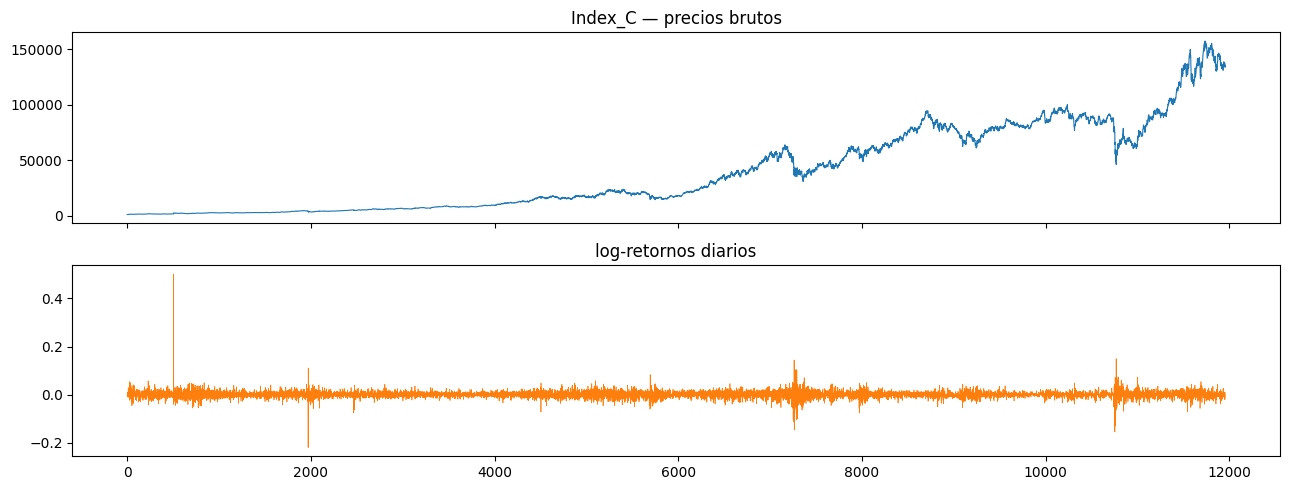

In [2]:
data  = load_hackathon_data(DATA_DIR)
idx   = data["train_indices"]
serie = idx[IDX].dropna().values

log_rets  = np.diff(np.log(serie))
vol_anual = log_rets[-252:].std() * np.sqrt(252)

print(f"{IDX}: {len(serie)} días  |  min={serie.min():,.0f}  max={serie.max():,.0f}  último={serie[-1]:,.0f}")
print(f"  volatilidad anual (último año) ~ {vol_anual:.1%}")

fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax[0].plot(serie, lw=0.8);                         ax[0].set_title(f"{IDX} — precios brutos")
ax[1].plot(log_rets, lw=0.5, color="tab:orange");  ax[1].set_title("log-retornos diarios")
plt.tight_layout(); plt.show()

## 2. Referencia: baselines para C (suelo a batir)

Cargamos los baselines ya calculados en el notebook 01. El flat de C probablemente será bajo (serie sin mucha tendencia), así que es un suelo competitivo. Cualquier mejora sobre él será significativa dado que C es "defensiva" como B.

In [3]:
with open("results/baselines.json") as f:
    baselines = json.load(f)

print(f"Baselines para {IDX}:")
for bl, rmse in baselines[IDX].items():
    print(f"  {bl:<15} RMSE = {rmse:,.0f}")

best_bl   = min(baselines[IDX], key=baselines[IDX].get)
best_rmse = baselines[IDX][best_bl]
print(f"\nMejor baseline: {best_bl}  ->  RMSE = {best_rmse:,.0f}  (SUELO A BATIR)")

Baselines para Index_C:
  flat            RMSE = 8,805
  drift           RMSE = 90,421
  random_walk     RMSE = 9,756

Mejor baseline: flat  ->  RMSE = 8,805  (SUELO A BATIR)


## 3. ¿Sirve el macro? — verificación rápida del análisis

Confirmamos en el propio notebook lo que vimos en el análisis previo: la correlación macro→C es contemporánea pero no predictiva (cae a cero con lag), y `test_macro` no cubre los 252 días. Esto justifica NO usar macro como vía principal. Es una verificación medida que documenta la decisión.

In [4]:
macro_tr = data.get("train_macro")
macro_te = data.get("test_macro")

if macro_tr is not None:
    aux_full = align_aux_features(idx, macro_tr, macro_tr.columns)
    lr = np.diff(np.log(serie))
    print("corr(ret_C[t], Δmacro[t-lag]) — ¿predictivo?")
    for col in macro_tr.columns:
        m  = aux_full[col].values
        dm = np.diff(m) / (np.abs(m[:-1]) + 1e-9)
        for lag in (0, 1, 2):
            a, b = (lr, dm) if lag == 0 else (lr[lag:], dm[:-lag])
            n = min(len(a), len(b))
            cc = np.corrcoef(a[-n:], b[-n:])[0, 1]
            print(f"  {col:<20} lag={lag}: {cc:+.3f}")
    cobertura = len(macro_te) if macro_te is not None else 0
    print(f"\ntest_macro cubre {cobertura}/252 días del rollout "
          f"→ {'INSUFICIENTE para aux completo' if cobertura < 252 else 'OK'}")
else:
    print("Sin macro disponible.")

corr(ret_C[t], Δmacro[t-lag]) — ¿predictivo?
  Crude_Vitality       lag=0: +0.199
  Crude_Vitality       lag=1: -0.001
  Crude_Vitality       lag=2: -0.018
  Lumina_Reserve       lag=0: +0.088
  Lumina_Reserve       lag=1: -0.008
  Lumina_Reserve       lag=2: +0.023
  Capital_Cost_Index   lag=0: +0.165
  Capital_Cost_Index   lag=1: -0.045
  Capital_Cost_Index   lag=2: +0.016

test_macro cubre 173/252 días del rollout → INSUFICIENTE para aux completo


## 4. Modelo principal — LSTM en log-rets (sin macro)

Mismo enfoque validado en B: entrenamos en log-retornos (escala universal ~0.01), con dropout para evitar sobreajuste del ruido. Sin features macro porque el análisis mostró que no son predictivas más allá de la contemporaneidad. Este es nuestro caballo de batalla para C.

X_tr=(9346, 20, 1)  X_v=(2337, 20, 1)  n_features=1


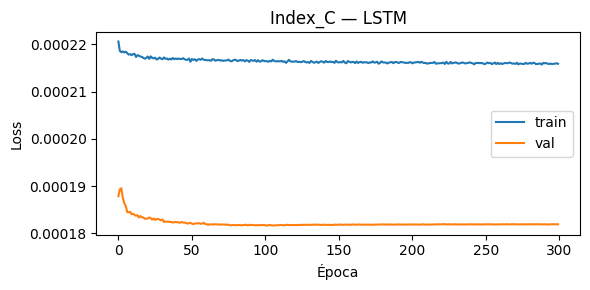

In [5]:
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

serie_train, _ = make_temporal_split(serie, val_days=VAL_DAYS, v_in=V_IN_SHARED)
X, y = make_window_dataset(serie_train, V_IN_SHARED, use_log_rets=True)
cut  = int(len(X) * 0.8)
X_tr, y_tr, X_v, y_v = X[:cut], y[:cut], X[cut:], y[cut:]
print(f"X_tr={X_tr.shape}  X_v={X_v.shape}  n_features={X.shape[2]}")

model_lstm = build_model("lstm", V_IN_SHARED, n_features=X.shape[2], units=64, dropout=0.2)
hist_lstm  = train_model(model_lstm, X_tr, y_tr, X_v, y_v, epochs=300)
plot_history(hist_lstm, title=f"{IDX} — LSTM")

### 4.1 Backtest de la LSTM simple

El RMSE de backtest 252d es el único indicador fiable. Comparamos contra el suelo del baseline para ver si la LSTM aporta valor real en el rollout autorregresivo (donde el error se acumula).

LSTM      RMSE backtest = 14,344  |  dir_acc = 36.25%
baseline  RMSE backtest = 8,805  (flat)


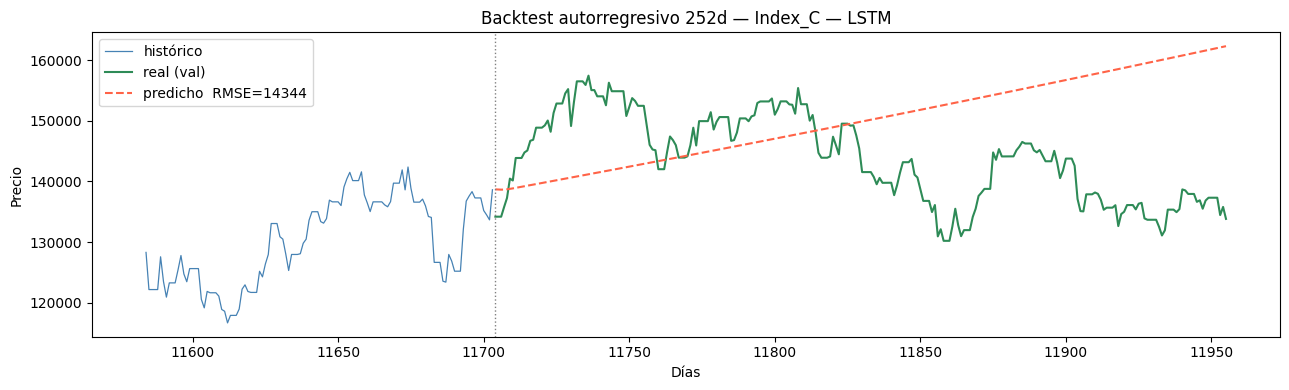

In [6]:
predict_fn_lstm = lambda x: model_lstm.predict(x, verbose=0).ravel()[0]
bt_lstm = backtest_autoregressive(predict_fn_lstm, serie, log_ret_mode=True)
print(f"LSTM      RMSE backtest = {bt_lstm['rmse']:,.0f}  |  dir_acc = {bt_lstm['dir_accuracy']:.2%}")
print(f"baseline  RMSE backtest = {best_rmse:,.0f}  ({best_bl})")
plot_rollout(serie, bt_lstm['preds'], index_name=f"{IDX} — LSTM", val_days=VAL_DAYS)

## 5. Ensemble de semillas — la apuesta sólida

Como vimos en B, el ensemble de 3 semillas entrena 3 LSTMs con inicializaciones distintas y promedia sus predicciones. Esto reduce el ruido idiosincrásico de cada modelo y suele dar el mayor salto en RMSE de backtest. Es nuestra apuesta principal para C.

  [seed 0]  RMSE val (ventana) = 0.01
  [seed 1]  RMSE val (ventana) = 0.01
  [seed 2]  RMSE val (ventana) = 0.01

  Ensemble (3 seeds)  ->  val RMSE (ventana) = 0.01
  [!] Llamar backtest_autoregressive(result["predict_fn"], ...) para el RMSE real

Ensemble  RMSE backtest = 9,004  |  dir_acc = 35.46%


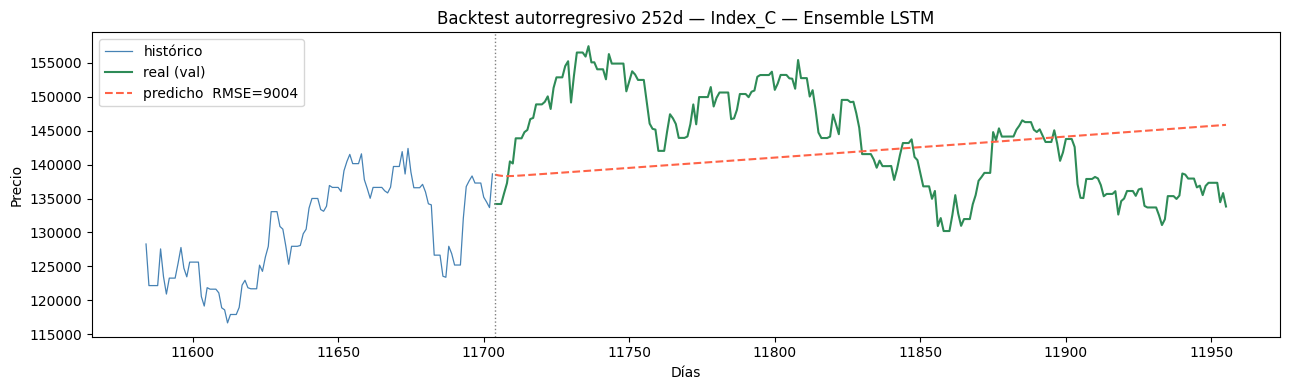

In [7]:
ens = train_ensemble(
    "lstm", X_tr, y_tr, X_v, y_v,
    v_in=V_IN_SHARED, n_features=X.shape[2],
    n_seeds=3, epochs=300, dropout=0.2,
)
bt_ens = backtest_autoregressive(ens["predict_fn"], serie, log_ret_mode=True)
print(f"\nEnsemble  RMSE backtest = {bt_ens['rmse']:,.0f}  |  dir_acc = {bt_ens['dir_accuracy']:.2%}")
plot_rollout(serie, bt_ens["preds"], index_name=f"{IDX} — Ensemble LSTM", val_days=VAL_DAYS)

## 7. Decisión final y guardado

Comparamos todos los candidatos en un diccionario y elegimos el menor RMSE de backtest. El macro solo se acepta si bate al ensemble **Y** si se documenta explícitamente la limitación de cobertura (79 días a rellenar en producción, notebook 09). Si el macro gana pero es marginal o tienen el mismo RMSE, la apuesta más segura es el ensemble limpio (sin riesgo de relleno).

In [9]:
# Inicializar bt_macro si no se definió en la celda 6
bt_macro = None

candidatos = {f"baseline_{best_bl}": best_rmse, "lstm": bt_lstm["rmse"], "ensemble": bt_ens["rmse"]}
if bt_macro is not None:
    candidatos["lstm_macro"] = bt_macro["rmse"]

print("Comparativa final (RMSE backtest 252d):")
for k, v in sorted(candidatos.items(), key=lambda kv: kv[1]):
    print(f"  {k:<20} {v:,.0f}")
ganador = min(candidatos, key=candidatos.get)
print(f"\nGanador: {ganador}")

candidatos = {f"baseline_{best_bl}": best_rmse, "lstm": bt_lstm["rmse"], "ensemble": bt_ens["rmse"]}
if bt_macro is not None:
    candidatos["lstm_macro"] = bt_macro["rmse"]

print("Comparativa final (RMSE backtest 252d):")
for k, v in sorted(candidatos.items(), key=lambda kv: kv[1]):
    print(f"  {k:<20} {v:,.0f}")
ganador = min(candidatos, key=candidatos.get)
print(f"\nGanador: {ganador}")

_tipo_map = {"flat": "baseline_flat", "drift": "baseline_drift", "random_walk": "baseline_rw"}

if ganador.startswith("baseline"):
    info = {"index": IDX, "owner": OWNER, "approach_type": _tipo_map[best_bl], "strategy": best_bl,
            "rmse_backtest_252d": float(best_rmse), "model_path": None, "log_ret_mode": False,
            "v_in": None, "n_features": 1, "aux_source": None, "aux_test_source": None,
            "aux_columns": None, "ghost_source_index": None, "ghost_lag": None,
            "notes": f"Baseline {best_bl} gana — NN no aporta en backtest 252d."}
elif ganador == "lstm_macro":
    model_m.save(MODEL_PATH)
    info = {"index": IDX, "owner": OWNER, "approach_type": "nn", "strategy": "lstm_macro",
            "rmse_backtest_252d": float(bt_macro["rmse"]), "model_path": MODEL_PATH, "log_ret_mode": True,
            "v_in": V_IN_SHARED, "n_features": int(Xm.shape[2]),
            "aux_source": "train_macro_factors.csv", "aux_test_source": "test_macro_factors.csv",
            "aux_columns": list(macro_tr.columns), "ghost_source_index": None, "ghost_lag": None,
            "notes": "LSTM+macro contemporáneo. OJO: test_macro cubre 173/252 → rellenar 79 días en notebook 09."}
    print("Guardado modelo:", MODEL_PATH)
else:
    if ganador == "ensemble":
        ens["models"][0].save(MODEL_PATH); approach, strat, rmse_w = "nn_ensemble", "lstm", bt_ens["rmse"]
        note = "Ensemble 3-seed LSTM (log-ret). Macro descartado: corr no predictiva + cobertura 173/252."
    else:
        model_lstm.save(MODEL_PATH); approach, strat, rmse_w = "nn", "lstm", bt_lstm["rmse"]
        note = "LSTM simple (log-ret). Macro descartado por análisis."
    info = {"index": IDX, "owner": OWNER, "approach_type": approach, "strategy": strat,
            "rmse_backtest_252d": float(rmse_w), "model_path": MODEL_PATH, "log_ret_mode": True,
            "v_in": V_IN_SHARED, "n_features": 1, "aux_source": None, "aux_test_source": None,
            "aux_columns": None, "ghost_source_index": None, "ghost_lag": None, "notes": note}
    print("Guardado modelo:", MODEL_PATH)

with open("results/index_C.json", "w") as f:
    json.dump(info, f, indent=2)
print("Guardado: results/index_C.json")
print(json.dumps(info, indent=2))

Comparativa final (RMSE backtest 252d):
  baseline_flat        8,805
  ensemble             9,004
  lstm                 14,344

Ganador: baseline_flat
Comparativa final (RMSE backtest 252d):
  baseline_flat        8,805
  ensemble             9,004
  lstm                 14,344

Ganador: baseline_flat
Guardado: results/index_C.json
{
  "index": "Index_C",
  "owner": "dani",
  "approach_type": "baseline_flat",
  "strategy": "flat",
  "rmse_backtest_252d": 8804.679666403612,
  "model_path": null,
  "log_ret_mode": false,
  "v_in": null,
  "n_features": 1,
  "aux_source": null,
  "aux_test_source": null,
  "aux_columns": null,
  "ghost_source_index": null,
  "ghost_lag": null,
  "notes": "Baseline flat gana \u2014 NN no aporta en backtest 252d."
}


## 8. Generación de predicciones de producción para los 252 días futuros

Hacemos un rollout nuevo usando la serie COMPLETA como contexto (sin reservar validación). Esto genera las predicciones reales para los 252 días del futuro que se entregan.

In [12]:
from utils import precios_a_logret, predict_autoregressive

# Seleccionar la función predict del ganador O generar predicciones baseline
preds_produccion = None

if ganador == "ensemble":
    predict_fn_prod = ens['predict_fn']
    print("Usando ensemble ganador para predicciones de producción")
    
    log_rets_full = precios_a_logret(serie)
    ventana_prod = np.zeros((V_IN_SHARED, 1), dtype=np.float32)
    ventana_prod[:, 0] = log_rets_full[-V_IN_SHARED:]
    precio_inicial = float(serie[-1])
    
    preds_produccion = predict_autoregressive(
        predict_fn_prod, ventana_prod, 252,
        precio_inicial=precio_inicial,
        aux_data=None, clip_logret=0.5
    )
    
elif ganador == "lstm_macro":
    predict_fn_prod = predict_fn_m
    print("Usando LSTM+macro ganador para predicciones de producción")
    
    log_rets_full = precios_a_logret(serie)
    ventana_prod = np.zeros((V_IN_SHARED, 1), dtype=np.float32)
    ventana_prod[:, 0] = log_rets_full[-V_IN_SHARED:]
    precio_inicial = float(serie[-1])
    aux_full = align_aux_features(idx, macro_tr, list(macro_tr.columns)).values
    
    preds_produccion = predict_autoregressive(
        predict_fn_prod, ventana_prod, 252,
        precio_inicial=precio_inicial,
        aux_data=aux_full, clip_logret=0.5
    )
    
elif ganador == "lstm":
    predict_fn_prod = predict_fn_lstm
    print("Usando LSTM simple ganadora para predicciones de producción")
    
    log_rets_full = precios_a_logret(serie)
    ventana_prod = np.zeros((V_IN_SHARED, 1), dtype=np.float32)
    ventana_prod[:, 0] = log_rets_full[-V_IN_SHARED:]
    precio_inicial = float(serie[-1])
    
    preds_produccion = predict_autoregressive(
        predict_fn_prod, ventana_prod, 252,
        precio_inicial=precio_inicial,
        aux_data=None, clip_logret=0.5
    )
    
elif ganador.startswith("baseline"):
    print(f"Ganador es baseline {best_bl} → generando predicciones con la función baseline")
    
    # Generar predicciones baseline directamente (sin modelo)
    _bl_fn = {"flat": baseline_flat, "drift": baseline_drift, "random_walk": baseline_random_walk}
    preds_produccion = _bl_fn[best_bl](serie, 252)
    
else:
    print("Ganador desconocido, intentando fallback LSTM")
    predict_fn_prod = predict_fn_lstm
    log_rets_full = precios_a_logret(serie)
    ventana_prod = np.zeros((V_IN_SHARED, 1), dtype=np.float32)
    ventana_prod[:, 0] = log_rets_full[-V_IN_SHARED:]
    precio_inicial = float(serie[-1])
    
    preds_produccion = predict_autoregressive(
        predict_fn_prod, ventana_prod, 252,
        precio_inicial=precio_inicial,
        aux_data=None, clip_logret=0.5
    )

# Resumen
if preds_produccion is not None:
    print(f"\n✓ Predicciones generadas: {len(preds_produccion)} valores")
    print(f"  min={preds_produccion.min():,.0f}  max={preds_produccion.max():,.0f}")
    print(f"  primeros 5: {preds_produccion[:5]}")
else:
    print("Error: no se pudieron generar predicciones")

Ganador es baseline flat → generando predicciones con la función baseline

✓ Predicciones generadas: 252 valores
  min=133,822  max=133,822
  primeros 5: [133821.92831682 133821.92831682 133821.92831682 133821.92831682
 133821.92831682]


In [13]:
# Guardar predicciones en CSV para el compañero
if preds_produccion is not None:
    test_dates = data.get('test_dates')
    
    if test_dates is not None:
        fechas = test_dates.index
        print("✓ Usando fechas del test_dates.csv")
    else:
        import pandas as pd
        from datetime import timedelta
        
        ultimo_dia = idx.index[-1]
        fechas = pd.date_range(start=ultimo_dia + timedelta(days=1), periods=252, freq='D')
        print(f"⚠️ Generadas fechas aproximadas (idealmente usar test_dates.csv)")
    
    df_submission = pd.DataFrame({
        'Date': fechas,
        f'pred_{IDX}': preds_produccion
    })
    
    csv_path = f'results/{OWNER}_{IDX}_predicciones_252d.csv'
    df_submission.to_csv(csv_path, index=False)
    print(f"✓ Guardado: {csv_path}")
    
    print(f"\n{IDX} — Predicciones de producción:")
    print(df_submission.head(10))
else:
    print("No hay predicciones para guardar.")

⚠️ Generadas fechas aproximadas (idealmente usar test_dates.csv)
✓ Guardado: results/dani_Index_C_predicciones_252d.csv

Index_C — Predicciones de producción:
        Date   pred_Index_C
0 2028-12-13  133821.928317
1 2028-12-14  133821.928317
2 2028-12-15  133821.928317
3 2028-12-16  133821.928317
4 2028-12-17  133821.928317
5 2028-12-18  133821.928317
6 2028-12-19  133821.928317
7 2028-12-20  133821.928317
8 2028-12-21  133821.928317
9 2028-12-22  133821.928317
